# Análisis de robustez en escenarios sintéticos

Este notebook analiza los resultados obtenidos al aplicar los métodos de estimación de movimiento en distintos escenarios.

Los escenarios sintéticos permiten evaluar de forma controlada cómo afectan el ruido, los cambios de iluminación y la velocidad del objeto al rendimiento de cada método.

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

project_dir = Path(r"C:\Users\34689\Desktop\Glole\U\masterus\percep")

summary_path = project_dir / "outputs" / "plots" / "synthetic" / "synthetic_experiments_summary.csv"

print("Summary path:", summary_path)
print("File exists:", summary_path.exists())

if not summary_path.exists():
    raise FileNotFoundError(f"Summary file not found: {summary_path}")

summary_df = pd.read_csv(summary_path)

print("Columns:", summary_df.columns.tolist())
print("Rows:", len(summary_df))

summary_df


Summary path: C:\Users\34689\Desktop\Glole\U\masterus\percep\outputs\plots\synthetic\synthetic_experiments_summary.csv
File exists: True
Columns: ['scenario', 'method', 'detections', 'mean_displacement', 'median_displacement', 'p95_displacement', 'max_displacement', 'mean_area', 'mean_points_per_frame']
Rows: 8


,scenario,method,detections,mean_displacement,median_displacement,p95_displacement,max_displacement,mean_area,mean_points_per_frame
0,clean,frame_difference,156,6.955036,5.000000,10.770330,60.000000,820.724359,NaN
1,clean,lucas_kanade,179,4.327446,4.244777,5.832163,5.844762,NaN,7.000000
2,noisy,frame_difference,157,16.655112,9.219544,36.400549,60.000000,816.875796,NaN
3,noisy,lucas_kanade,179,6.418432,5.088116,14.571434,29.161133,NaN,26.167598
4,light_change,frame_difference,165,20.038274,5.000000,126.659405,150.632002,2097.148485,NaN
5,light_change,lucas_kanade,179,4.381356,4.286350,5.837646,6.290913,NaN,7.000000
6,fast_motion,frame_difference,158,9.698694,9.000000,21.394576,44.102154,1776.588608,NaN
7,fast_motion,lucas_kanade,179,7.405528,7.999954,10.819512,11.690625,NaN,7.000000


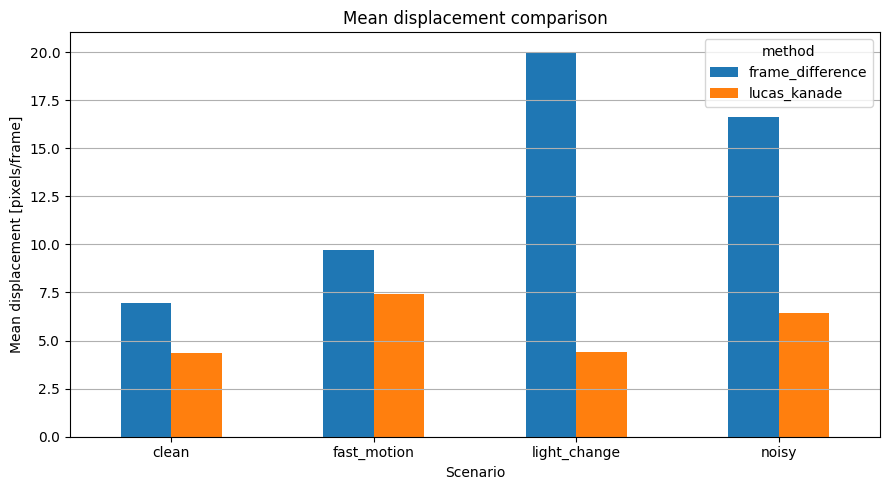

Saved at: C:\Users\34689\Desktop\Glole\U\masterus\percep\outputs\plots\synthetic\summary_mean_displacement.png


In [7]:
mean_disp_plot = project_dir / "outputs" / "plots" / "synthetic" / "summary_mean_displacement.png"

pivot_mean = summary_df.pivot(
    index="scenario",
    columns="method",
    values="mean_displacement"
)

pivot_mean.plot(kind="bar", figsize=(9, 5))

plt.ylabel("Mean displacement [pixels/frame]")
plt.xlabel("Scenario")
plt.title("Mean displacement comparison")
plt.grid(axis="y")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(mean_disp_plot, dpi=150, bbox_inches="tight")
plt.show()

print("Saved at:", mean_disp_plot)

In [12]:
median_disp_plot = synthetic_plots_dir / "summary_median_displacement.png"

pivot_median = summary_df.pivot(
    index="scenario",
    columns="method",
    values="median_displacement"
)

pivot_median.plot(kind="bar", figsize=(9, 5))

plt.ylabel("Median displacement [pixels/frame]")
plt.xlabel("Scenario")
plt.title("Median displacement comparison")
plt.grid(axis="y")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(median_disp_plot, dpi=150, bbox_inches="tight")
plt.show()

print("Saved at:", median_disp_plot)

NameError: name 'synthetic_plots_dir' is not defined

In [ ]:
p95_disp_plot = synthetic_plots_dir / "summary_p95_displacement.png"

pivot_p95 = summary_df.pivot(
    index="scenario",
    columns="method",
    values="p95_displacement"
)

pivot_p95.plot(kind="bar", figsize=(9, 5))

plt.ylabel("P95 displacement [pixels/frame]")
plt.xlabel("Scenario")
plt.title("P95 displacement comparison")
plt.grid(axis="y")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(p95_disp_plot, dpi=150, bbox_inches="tight")
plt.show()

print("Saved at:", p95_disp_plot)

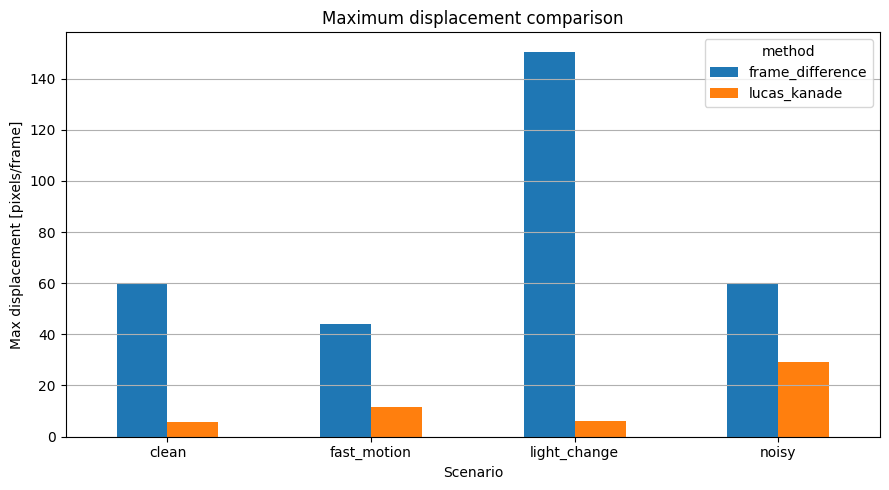

Saved at: C:\Users\34689\Desktop\Glole\U\masterus\percep\outputs\plots\synthetic\summary_max_displacement.png


In [8]:
max_disp_plot = project_dir / "outputs" / "plots" / "synthetic" / "summary_max_displacement.png"

pivot_max = summary_df.pivot(
    index="scenario",
    columns="method",
    values="max_displacement"
)

pivot_max.plot(kind="bar", figsize=(9, 5))

plt.ylabel("Max displacement [pixels/frame]")
plt.xlabel("Scenario")
plt.title("Maximum displacement comparison")
plt.grid(axis="y")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(max_disp_plot, dpi=150, bbox_inches="tight")
plt.show()

print("Saved at:", max_disp_plot)

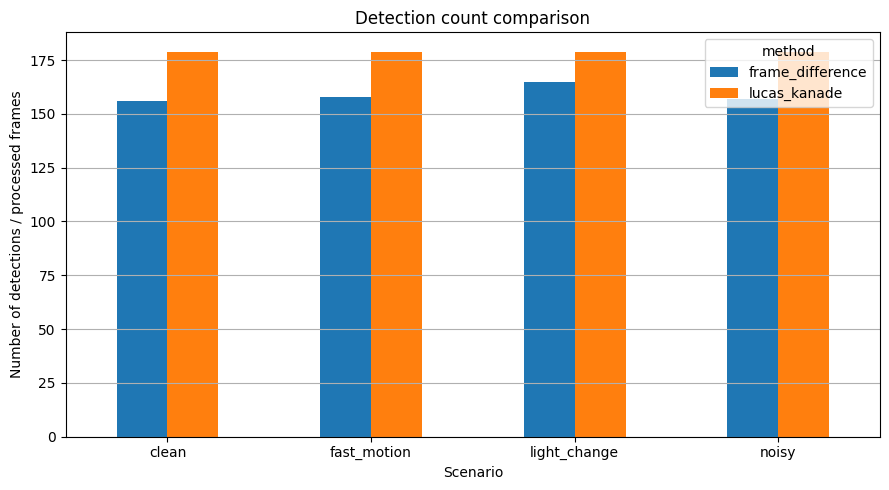

Saved at: C:\Users\34689\Desktop\Glole\U\masterus\percep\outputs\plots\synthetic\summary_detections.png


In [9]:
detections_plot = project_dir / "outputs" / "plots" / "synthetic" / "summary_detections.png"

pivot_detections = summary_df.pivot(
    index="scenario",
    columns="method",
    values="detections"
)

pivot_detections.plot(kind="bar", figsize=(9, 5))

plt.ylabel("Number of detections / processed frames")
plt.xlabel("Scenario")
plt.title("Detection count comparison")
plt.grid(axis="y")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(detections_plot, dpi=150, bbox_inches="tight")
plt.show()

print("Saved at:", detections_plot)

In [10]:
qualitative_summary = pd.DataFrame({
    "Scenario": [
        "Clean",
        "Noisy",
        "Light change / shadow",
        "Fast motion"
    ],
    "Frame difference behavior": [
        "Works correctly, but the centroid may jump because it detects changed regions, not the full object.",
        "Still detects the moving object, but noise can create false motion regions.",
        "Clearly affected by illumination and shadow changes, producing larger detected areas and unstable centroids.",
        "Detects motion, but the detected moving region becomes larger due to the faster object displacement."
    ],
    "Lucas-Kanade behavior": [
        "Stable tracking of feature points.",
        "More sensitive to noisy points, increasing the maximum displacement.",
        "More stable than frame difference under illumination changes.",
        "Works, but displacement increases and points could be lost for stronger motion."
    ],
    "Main conclusion": [
        "Both methods are valid in controlled conditions.",
        "Noise affects both methods, especially Lucas-Kanade if false points are tracked.",
        "Lucas-Kanade is more robust than frame difference against lighting changes.",
        "Fast motion is challenging because frame-to-frame displacement increases."
    ]
})

qualitative_summary

,Scenario,Frame difference behavior,Lucas-Kanade behavior,Main conclusion
0,Clean,"Works correctly, but the centroid may jump bec...",Stable tracking of feature points.,Both methods are valid in controlled conditions.
1,Noisy,"Still detects the moving object, but noise can...","More sensitive to noisy points, increasing the...","Noise affects both methods, especially Lucas-K..."
2,Light change / shadow,Clearly affected by illumination and shadow ch...,More stable than frame difference under illumi...,Lucas-Kanade is more robust than frame differe...
3,Fast motion,"Detects motion, but the detected moving region...","Works, but displacement increases and points c...",Fast motion is challenging because frame-to-fr...
